<a href="https://colab.research.google.com/github/VrishankDesai/Ai-in-healthcare/blob/main/Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
data = load_breast_cancer()
X = data.data        # 30 features (radius, texture, smoothness, etc.)
y = data.target      # 0 = Malignant, 1 = Benign

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)   # ['malignant', 'benign']

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


In [3]:
# ─────────────────────────────────────────
# 2. TRAIN TEST SPLIT
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 455, Test size: 114


In [4]:
# ─────────────────────────────────────────
# 3. SCALE FEATURES
# ─────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [5]:
# ─────────────────────────────────────────
# 4. TRAIN LOGISTIC REGRESSION MODEL
# ─────────────────────────────────────────
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [6]:
# ─────────────────────────────────────────
# 5. PREDICTIONS
# ─────────────────────────────────────────
y_pred = model.predict(X_test)

In [7]:
# ─────────────────────────────────────────
# 6. CLASSIFICATION REPORT
# ─────────────────────────────────────────
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=data.target_names))


── Classification Report ──
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



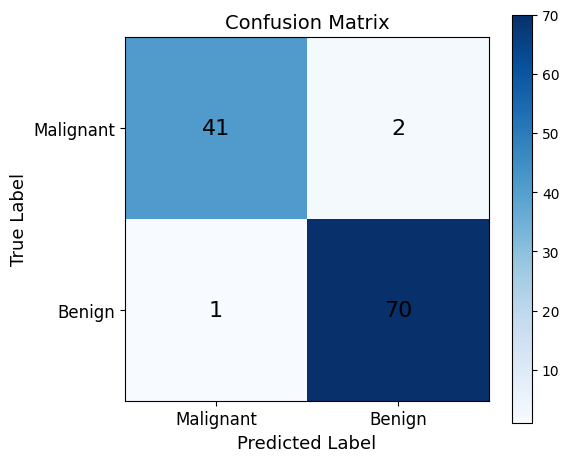

In [8]:
# ─────────────────────────────────────────
# 7. CONFUSION MATRIX PLOT
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Malignant", "Benign"], fontsize=12)
ax.set_yticklabels(["Malignant", "Benign"], fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("Confusion Matrix", fontsize=14)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                fontsize=16, color="black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

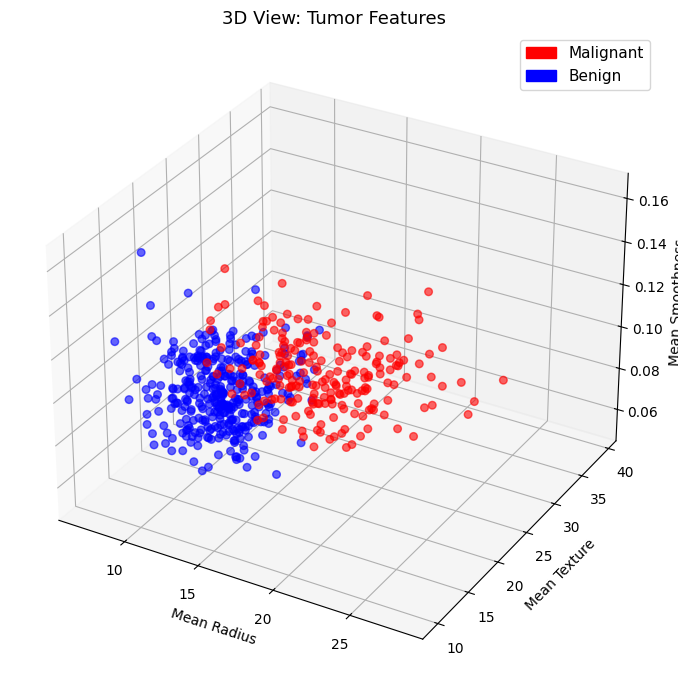

In [9]:
# ─────────────────────────────────────────
# 8. 3D SCATTER PLOT (mplot3d + mpatches)
# ─────────────────────────────────────────
idx_radius     = 0   # mean radius
idx_texture    = 1   # mean texture
idx_smoothness = 4   # mean smoothness

X_orig = data.data   # unscaled, for readable axis values

fig = plt.figure(figsize=(9, 7))
ax3d = fig.add_subplot(111, projection='3d')

colors = {0: 'red', 1: 'blue'}
labels = {0: 'Malignant', 1: 'Benign'}

for cls in [0, 1]:
    mask = y == cls
    ax3d.scatter(
        X_orig[mask, idx_radius],
        X_orig[mask, idx_texture],
        X_orig[mask, idx_smoothness],
        c=colors[cls],
        label=labels[cls],
        alpha=0.6,
        s=30
    )

ax3d.set_xlabel("Mean Radius", fontsize=10)
ax3d.set_ylabel("Mean Texture", fontsize=10)
ax3d.set_zlabel("Mean Smoothness", fontsize=10)
ax3d.set_title("3D View: Tumor Features", fontsize=13)

mal_patch = mpatches.Patch(color='red',  label='Malignant')
ben_patch = mpatches.Patch(color='blue', label='Benign')
ax3d.legend(handles=[mal_patch, ben_patch], fontsize=11)

plt.tight_layout()
plt.show()